#### Reference Paper: https://pmc.ncbi.nlm.nih.gov/articles/PMC11389500/

### Three-Class Synthetic Cardiovascular Disease Dataset

This notebook generates a synthetic dataset for **three-class** cardiovascular disease classification:

| Label | Class | Clinical definition |
|-------|-------|---------------------|
| 0 | Healthy | No diagnosed cardiovascular disease |
| 1 | Coronary Artery Disease (CAD) | Atherosclerotic narrowing of coronary arteries causing myocardial ischemia |
| 2 | Heart Failure (HF) | Inability of the heart to pump enough blood to meet the body's needs |

**Rationale for three classes.** Narrowing the target space from six to three focuses the model on the two most prevalent and clinically distinct CVD diagnoses (per WHO and AHA disease-burden reports), keeps class boundaries sharp, and improves interpretability for downstream models.

**Rationale for feature set.** Starting from 18 features in the original Kaggle 70k and Cleveland-combined merge, two redundant pairs have been collapsed:

- `fasting_blood_sugar` (binary > 120 mg/dL) is subsumed by the 3-level `glucose_level` category, which already encodes the diabetes threshold.
- `physical_activity` (self-reported binary) overlaps with the exercise-response signal captured by `st_slope`; the exercise-ECG finding is retained because it is diagnostic rather than self-reported.

This yields a **16-feature** predictor space. Every feature's numeric range and its class-conditional distribution are grounded in published clinical references (AHA, CDC, NHLBI, WHO). Exact URLs and the medical justification per feature are listed in the `feature_sources` cell below.


In [1]:
# Synthetic Three-Class Cardiovascular Disease Dataset Generation
#
# This notebook generates a clinically-informed synthetic dataset for
# three-class cardiovascular disease (CVD) classification. The feature
# set is derived by merging two widely-used public CVD datasets:
#
#   Dataset I  : Kaggle Cardiovascular Disease Dataset (70,000 records, 11 features)
#   Dataset II : Combined Heart Disease Dataset - Cleveland, Hungarian,
#                Switzerland, Long Beach VA, Statlog (1,190 records, 11 features)
#
# After dropping two redundant feature pairs (fasting_blood_sugar vs
# glucose_level, and physical_activity vs st_slope), the unified feature
# space contains 16 predictors.
#
# TARGET CLASSES:
#   0 = Healthy
#   1 = Coronary Artery Disease (CAD)
#   2 = Heart Failure (HF)
#
# Every feature's range and its association with each class is grounded
# in AHA, CDC, NHLBI, and WHO clinical guidelines (see feature_sources).
#
# Tools Used : Python 3.x, NumPy, Pandas, SciPy, Matplotlib, Seaborn


In [2]:
# 1: Import Required Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')
np.random.seed(42)

print("All libraries imported successfully.")
print(f"NumPy version  : {np.__version__}")
print(f"Pandas version : {pd.__version__}")

All libraries imported successfully.
NumPy version  : 1.26.3
Pandas version : 2.2.0


In [3]:
# 2: Define the Merged Feature Space (16 Features)
#
# Starting from 18 features in the original merge, two redundant pairs
# have been collapsed into a single representative each:
#
#   fasting_blood_sugar  -> dropped  (glucose_level retained; its 3-level
#                                     encoding already spans the diabetes
#                                     threshold captured by fasting_bs)
#   physical_activity    -> dropped  (st_slope retained; exercise-ECG slope
#                                     is the diagnostic exercise-response
#                                     signal, while self-reported activity
#                                     is a lifestyle proxy)
#
# FROM DATASET I (Kaggle 70k):
#   age, gender, height_cm, weight_kg, systolic_bp, diastolic_bp,
#   cholesterol_level, glucose_level, smoking, alcohol_intake
#
# FROM DATASET II (Cleveland Combined):
#   chest_pain_type, resting_ecg, max_heart_rate, exercise_angina,
#   oldpeak, st_slope
#
# TARGET VARIABLE (Three-Class):
#   0 = Healthy (No CVD)
#   1 = Coronary Artery Disease (CAD)
#   2 = Heart Failure (HF)

feature_descriptions = {
    "age"              : "Age of the patient in years (continuous, 20-95)",
    "gender"           : "Biological sex (0 = Female, 1 = Male)",
    "height_cm"        : "Height in centimetres (continuous, 140-210)",
    "weight_kg"        : "Weight in kilograms (continuous, 35-180)",
    "systolic_bp"      : "Systolic blood pressure in mmHg (continuous, 85-230)",
    "diastolic_bp"     : "Diastolic blood pressure in mmHg (continuous, 50-140)",
    "cholesterol_level": "Total cholesterol category (1=Desirable <200, 2=Borderline 200-239, 3=High >=240 mg/dL)",
    "glucose_level"    : "Fasting glucose category (1=Normal <100, 2=Prediabetes 100-125, 3=Diabetes >=126 mg/dL)",
    "smoking"          : "Current smoker (0=No, 1=Yes)",
    "alcohol_intake"   : "Regular alcohol consumption (0=No, 1=Yes)",
    "chest_pain_type"  : "Chest pain (1=Typical Angina, 2=Atypical Angina, 3=Non-Anginal, 4=Asymptomatic)",
    "resting_ecg"      : "Resting ECG result (0=Normal, 1=ST-T Abnormality, 2=LV Hypertrophy)",
    "max_heart_rate"   : "Maximum heart rate achieved during exercise (continuous, 55-210 bpm)",
    "exercise_angina"  : "Exercise-induced angina (0=No, 1=Yes)",
    "oldpeak"          : "ST depression induced by exercise relative to rest (continuous, 0.0-6.5 mm)",
    "st_slope"         : "Slope of peak exercise ST segment (1=Upsloping, 2=Flat, 3=Downsloping)",
}

print(f"Total number of features: {len(feature_descriptions)}")
print("\nFeature Descriptions:")
print("-" * 100)
for feat, desc in feature_descriptions.items():
    print(f"  {feat:<20s} : {desc}")


Total number of features: 16

Feature Descriptions:
----------------------------------------------------------------------------------------------------
  age                  : Age of the patient in years (continuous, 20-95)
  gender               : Biological sex (0 = Female, 1 = Male)
  height_cm            : Height in centimetres (continuous, 140-210)
  weight_kg            : Weight in kilograms (continuous, 35-180)
  systolic_bp          : Systolic blood pressure in mmHg (continuous, 85-230)
  diastolic_bp         : Diastolic blood pressure in mmHg (continuous, 50-140)
  cholesterol_level    : Total cholesterol category (1=Desirable <200, 2=Borderline 200-239, 3=High >=240 mg/dL)
  glucose_level        : Fasting glucose category (1=Normal <100, 2=Prediabetes 100-125, 3=Diabetes >=126 mg/dL)
  smoking              : Current smoker (0=No, 1=Yes)
  alcohol_intake       : Regular alcohol consumption (0=No, 1=Yes)
  chest_pain_type      : Chest pain (1=Typical Angina, 2=Atypical Angina

In [4]:
# 3: Clinical Sources for Feature Ranges and Disease Associations
#
# Each feature's numeric range used in the generator, together with its
# relationship to the three target classes (Healthy / CAD / HF), is
# grounded in peer-reviewed clinical guidelines and reputable public
# cardiology references. The URLs below point to the specific guideline
# or educational page on which the distribution parameters are based.
# All URLs verified live (content-checked, not just HTTP 200) at time
# of writing.

feature_sources = {
    "age": {
        "url": "https://www.aafp.org/pubs/afp/afp-community-blog/entry/coronary-artery-calcium-is-a-common-finding-in-older-adults.html",
        "range_used": "20-95 years",
        "class_relevance": (
            "Healthy cohort centred at ~45 yrs; CAD diagnosis peaks 55-65 yrs; "
            "HF prevalence is highest in >=65 yrs (WHO CVD fact sheet)."
        ),
    },
    "gender": {
        "url": "https://www.cdc.gov/heart-disease/about/men-and-heart-disease.html",
        "range_used": "0 = Female, 1 = Male",
        "class_relevance": (
            "CAD incidence is ~2x higher in men before age 65. HF is near "
            "gender-balanced but skews slightly male at younger ages."
        ),
    },
    "height_cm & weight_kg (BMI proxy)": {
        "url": "https://www.cdc.gov/bmi/about/",
        "range_used": "height 140-210 cm, weight 35-180 kg (BMI ~18-45)",
        "class_relevance": (
            "Normal BMI 18.5-24.9, Overweight 25-29.9, Obese >=30. Higher "
            "BMI is an independent risk factor for both CAD and HF; the "
            "disease cohorts average BMI ~29-31 vs ~25 in Healthy."
        ),
    },
    "systolic_bp & diastolic_bp": {
        "url": "https://www.heart.org/en/health-topics/high-blood-pressure/understanding-blood-pressure-readings",
        "range_used": "systolic 85-230 mmHg, diastolic 50-140 mmHg",
        "class_relevance": (
            "AHA categories: Normal <120/<80, Elevated 120-129/<80, "
            "Stage 1 HTN 130-139/80-89, Stage 2 HTN >=140/>=90. "
            "Hypertension is the single largest driver of both CAD and HF."
        ),
    },
    "cholesterol_level": {
        "url": "https://www.cdc.gov/cholesterol/about/",
        "range_used": "1 = Desirable <200, 2 = Borderline 200-239, 3 = High >=240 mg/dL",
        "class_relevance": (
            "Elevated total cholesterol promotes atherosclerosis and is "
            "a primary CAD risk factor. Healthy cohort is ~75% in the "
            "desirable band; CAD cohort is ~60% in the high band."
        ),
    },
    "glucose_level": {
        "url": "https://www.cdc.gov/diabetes/diabetes-testing/",
        "range_used": "1 = Normal <100, 2 = Prediabetes 100-125, 3 = Diabetes >=126 mg/dL",
        "class_relevance": (
            "Diabetes roughly doubles CVD risk and is a leading HF "
            "comorbidity. Encoded as 3 categories so the diabetes "
            "threshold is represented without needing a separate binary."
        ),
    },
    "smoking": {
        "url": "https://www.cdc.gov/tobacco/campaign/tips/diseases/heart-disease-stroke.html",
        "range_used": "0 = No, 1 = Yes",
        "class_relevance": (
            "Smokers have 2-4x increased CAD risk (CDC). Prevalence in the "
            "CAD cohort is elevated (~45%) vs ~10% in Healthy."
        ),
    },
    "alcohol_intake": {
        "url": "https://www.heart.org/en/healthy-living/healthy-eating/eat-smart/nutrition-basics/alcohol-and-heart-health",
        "range_used": "0 = No, 1 = Yes",
        "class_relevance": (
            "Heavy alcohol use contributes to alcoholic cardiomyopathy and "
            "HF; modest effect on CAD risk. HF cohort rate ~22% vs ~8% in Healthy."
        ),
    },
    "chest_pain_type": {
        "url": "https://www.nhlbi.nih.gov/health/angina/types",
        "range_used": "1 = Typical Angina, 2 = Atypical, 3 = Non-Anginal, 4 = Asymptomatic",
        "class_relevance": (
            "CAD often presents as asymptomatic ischemia or atypical angina; "
            "typical exertional angina is also a classic CAD marker. NHLBI "
            "describes stable/unstable/microvascular/variant/refractory types. "
            "Encoding follows Cleveland-dataset convention."
        ),
    },
    "resting_ecg": {
        "url": "https://www.nhlbi.nih.gov/health/heart-tests",
        "range_used": "0 = Normal, 1 = ST-T Abnormality, 2 = LV Hypertrophy",
        "class_relevance": (
            "ST-T abnormalities are common in CAD (ischemia); LV "
            "hypertrophy is characteristic of chronic pressure/volume "
            "overload seen in HF."
        ),
    },
    "max_heart_rate": {
        "url": "https://www.heart.org/en/healthy-living/fitness/fitness-basics/target-heart-rates",
        "range_used": "55-210 bpm",
        "class_relevance": (
            "Predicted max HR ~= 220 - age. Chronotropic incompetence "
            "(reduced peak HR) is a hallmark of both CAD and HF; Healthy "
            "cohort reaches ~90%+ of age-predicted max."
        ),
    },
    "exercise_angina": {
        "url": "https://www.nhlbi.nih.gov/health/angina",
        "range_used": "0 = No, 1 = Yes",
        "class_relevance": (
            "Exercise-induced angina is highly specific for obstructive CAD "
            "and also elevated in HF of ischemic etiology."
        ),
    },
    "oldpeak (ST depression)": {
        "url": "https://my.clevelandclinic.org/health/diagnostics/16984-exercise-stress-test",
        "range_used": "0.0-6.5 mm",
        "class_relevance": (
            "ST depression >=1 mm on exercise ECG indicates myocardial "
            "ischemia. Healthy cohort mean ~0.2 mm; CAD and HF cohorts "
            "show markedly elevated means (~2.0 mm)."
        ),
    },
    "st_slope": {
        "url": "https://www.ncbi.nlm.nih.gov/books/NBK459364/",
        "range_used": "1 = Upsloping, 2 = Flat, 3 = Downsloping",
        "class_relevance": (
            "Downsloping or flat ST segment during peak exercise indicates "
            "ischemia; upsloping is generally benign. Used in the Duke "
            "Treadmill Score for CAD risk stratification."
        ),
    },
}

print(f"Documented clinical sources for {len(feature_sources)} feature groups.\n")
print("-" * 100)
for feat, info in feature_sources.items():
    print(f"  {feat}")
    print(f"    Range used     : {info['range_used']}")
    print(f"    Source         : {info['url']}")
    print(f"    Class relevance: {info['class_relevance']}")
    print()


Documented clinical sources for 14 feature groups.

----------------------------------------------------------------------------------------------------
  age
    Range used     : 20-95 years
    Source         : https://www.aafp.org/pubs/afp/afp-community-blog/entry/coronary-artery-calcium-is-a-common-finding-in-older-adults.html
    Class relevance: Healthy cohort centred at ~45 yrs; CAD diagnosis peaks 55-65 yrs; HF prevalence is highest in >=65 yrs (WHO CVD fact sheet).

  gender
    Range used     : 0 = Female, 1 = Male
    Source         : https://www.cdc.gov/heart-disease/about/men-and-heart-disease.html
    Class relevance: CAD incidence is ~2x higher in men before age 65. HF is near gender-balanced but skews slightly male at younger ages.

  height_cm & weight_kg (BMI proxy)
    Range used     : height 140-210 cm, weight 35-180 kg (BMI ~18-45)
    Source         : https://www.cdc.gov/bmi/about/
    Class relevance: Normal BMI 18.5-24.9, Overweight 25-29.9, Obese >=30. Higher B

In [5]:
# 4: Clinically-Informed Distribution Parameters Per Disease Class
#
# Each of the three classes is assigned realistic probability distributions
# for every feature. Distribution parameters are informed by:
#   - The clinical guidelines referenced in `feature_sources` above
#   - Population statistics from Dataset I (Kaggle 70k) and Dataset II
#     (Cleveland + 4 others)
#   - Published epidemiological data on CAD and HF presentations
#
# Continuous features  : Gaussian (mean, std) with clinical clipping
# Categorical features : probability vectors
# Binary features      : Bernoulli probability

disease_profiles = {

    # ----- CLASS 0: HEALTHY -----
    # AHA normotensive, CDC normal BMI / cholesterol / glucose.
    "Healthy": {
        "n": 15000,
        "age": (45, 12),
        "gender_male_prob": 0.50,
        "height_cm": (168, 9),
        "weight_kg": (70, 12),                     # BMI ~24.8 (normal)
        "systolic_bp": (118, 9),                   # AHA "Normal" (<120)
        "diastolic_bp": (76, 7),                   # AHA "Normal" (<80)
        "cholesterol_level": [0.75, 0.18, 0.07],   # mostly <200 mg/dL
        "glucose_level":     [0.82, 0.12, 0.06],   # mostly <100 mg/dL
        "smoking_prob": 0.10,
        "alcohol_prob": 0.08,
        "chest_pain_type":   [0.60, 0.25, 0.10, 0.05],
        "resting_ecg":       [0.80, 0.15, 0.05],   # mostly normal
        "max_heart_rate":    (162, 16),            # ~92% of 220-age
        "exercise_angina_prob": 0.04,
        "oldpeak":           (0.2, 0.3),           # <0.5 mm
        "st_slope":          [0.75, 0.20, 0.05],   # mostly upsloping
    },

    # ----- CLASS 1: CORONARY ARTERY DISEASE (CAD) -----
    # Atherosclerotic/ischemic profile: older, male-predominant, dyslipidemic,
    # hypertensive, asymptomatic-or-atypical chest pain, impaired peak HR,
    # ST depression, non-upsloping ST.
    "Coronary Artery Disease": {
        "n": 15000,
        "age": (60, 10),
        "gender_male_prob": 0.72,
        "height_cm": (167, 9),
        "weight_kg": (82, 14),                     # BMI ~29 (overweight)
        "systolic_bp": (148, 18),                  # Stage 2 HTN common
        "diastolic_bp": (90, 11),
        "cholesterol_level": [0.10, 0.28, 0.62],   # mostly >=240 mg/dL
        "glucose_level":     [0.35, 0.32, 0.33],
        "smoking_prob": 0.45,                      # CDC: 2-4x CAD risk
        "alcohol_prob": 0.20,
        "chest_pain_type":   [0.08, 0.14, 0.30, 0.48],  # asymptomatic/atypical
        "resting_ecg":       [0.22, 0.50, 0.28],        # ST-T abnormalities
        "max_heart_rate":    (128, 22),                  # chronotropic incompetence
        "exercise_angina_prob": 0.65,
        "oldpeak":           (2.3, 1.0),                 # ischemic ST depression
        "st_slope":          [0.10, 0.40, 0.50],         # flat/downsloping
    },

    # ----- CLASS 2: HEART FAILURE (HF) -----
    # Structural/functional failure: oldest cohort, LV hypertrophy on ECG,
    # markedly reduced peak HR, high diabetes comorbidity, wide systolic BP
    # spread (hypertensive drivers vs decompensated hypotension).
    "Heart Failure": {
        "n": 15000,
        "age": (68, 11),
        "gender_male_prob": 0.58,
        "height_cm": (166, 10),
        "weight_kg": (85, 15),                     # BMI ~30 (obese-class I)
        "systolic_bp": (136, 22),                  # wide: HTN drivers + hypotension
        "diastolic_bp": (82, 13),
        "cholesterol_level": [0.22, 0.35, 0.43],
        "glucose_level":     [0.30, 0.32, 0.38],   # diabetes common comorbidity
        "smoking_prob": 0.32,
        "alcohol_prob": 0.22,                      # alcoholic cardiomyopathy risk
        "chest_pain_type":   [0.18, 0.30, 0.32, 0.20],
        "resting_ecg":       [0.15, 0.35, 0.50],   # LV hypertrophy predominant
        "max_heart_rate":    (110, 24),            # markedly reduced
        "exercise_angina_prob": 0.48,
        "oldpeak":           (1.9, 1.1),
        "st_slope":          [0.15, 0.45, 0.40],
    },
}

print(f"Number of disease classes defined: {len(disease_profiles)}")
total_samples = sum(v["n"] for v in disease_profiles.values())
print(f"Total synthetic samples to generate: {total_samples}")
print("\nClass-wise sample distribution:")
for cls, params in disease_profiles.items():
    print(f"  {cls:<30s} : {params['n']} samples ({params['n']/total_samples*100:.1f}%)")


Number of disease classes defined: 3
Total synthetic samples to generate: 45000

Class-wise sample distribution:
  Healthy                        : 15000 samples (33.3%)
  Coronary Artery Disease        : 15000 samples (33.3%)
  Heart Failure                  : 15000 samples (33.3%)


In [6]:
# 5: Synthetic Data Generation Engine
#
# For each disease class we sample records from the defined distributions:
#   - Continuous features  -> np.random.normal() with clinical clipping
#   - Categorical features -> np.random.choice() with probability weights
#   - Binary features      -> np.random.binomial() with class-specific prob
#
# Clinical clipping bounds:
#   Age [20, 95], Height [140, 210], Weight [35, 180],
#   Systolic BP [85, 230], Diastolic BP [50, 140],
#   Max HR [55, 210], Oldpeak [0.0, 6.5]


def generate_class_data(class_name, params):
    """Generate synthetic patient records for a single disease class."""
    n = params["n"]

    # --- Continuous features with Gaussian sampling + clinical clipping ---
    age = np.clip(np.random.normal(*params["age"], n), 20, 95).astype(int)
    height_cm = np.clip(np.random.normal(*params["height_cm"], n), 140, 210).astype(int)
    weight_kg = np.clip(np.random.normal(*params["weight_kg"], n), 35, 180).round(1)
    systolic_bp = np.clip(np.random.normal(*params["systolic_bp"], n), 85, 230).astype(int)
    diastolic_bp = np.clip(np.random.normal(*params["diastolic_bp"], n), 50, 140).astype(int)
    max_heart_rate = np.clip(np.random.normal(*params["max_heart_rate"], n), 55, 210).astype(int)
    oldpeak = np.clip(np.random.normal(*params["oldpeak"], n), 0.0, 6.5).round(1)

    # --- Binary features (Bernoulli) ---
    gender = np.random.binomial(1, params["gender_male_prob"], n)
    smoking = np.random.binomial(1, params["smoking_prob"], n)
    alcohol_intake = np.random.binomial(1, params["alcohol_prob"], n)
    exercise_angina = np.random.binomial(1, params["exercise_angina_prob"], n)

    # --- Categorical features ---
    cholesterol_level = np.random.choice([1, 2, 3], n, p=params["cholesterol_level"])
    glucose_level = np.random.choice([1, 2, 3], n, p=params["glucose_level"])
    chest_pain_type = np.random.choice([1, 2, 3, 4], n, p=params["chest_pain_type"])
    resting_ecg = np.random.choice([0, 1, 2], n, p=params["resting_ecg"])
    st_slope = np.random.choice([1, 2, 3], n, p=params["st_slope"])

    df = pd.DataFrame({
        "age": age,
        "gender": gender,
        "height_cm": height_cm,
        "weight_kg": weight_kg,
        "systolic_bp": systolic_bp,
        "diastolic_bp": diastolic_bp,
        "cholesterol_level": cholesterol_level,
        "glucose_level": glucose_level,
        "smoking": smoking,
        "alcohol_intake": alcohol_intake,
        "chest_pain_type": chest_pain_type,
        "resting_ecg": resting_ecg,
        "max_heart_rate": max_heart_rate,
        "exercise_angina": exercise_angina,
        "oldpeak": oldpeak,
        "st_slope": st_slope,
        "target_disease": class_name,
    })

    return df


# --- Generate data for all disease classes ---
print("Generating synthetic data for each disease class...\n")

all_class_dfs = []
for class_name, params in disease_profiles.items():
    class_df = generate_class_data(class_name, params)
    all_class_dfs.append(class_df)
    print(f"  {class_name:<30s} - {len(class_df)} records generated")

# --- Concatenate and shuffle the entire dataset ---
synthetic_dataset = pd.concat(all_class_dfs, ignore_index=True)
synthetic_dataset = synthetic_dataset.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\nTotal synthetic dataset size: {len(synthetic_dataset)} records")
print(f"Number of features: {len(synthetic_dataset.columns) - 1}")
print(f"Number of classes: {synthetic_dataset['target_disease'].nunique()}")


Generating synthetic data for each disease class...

  Healthy                        - 15000 records generated
  Coronary Artery Disease        - 15000 records generated
  Heart Failure                  - 15000 records generated

Total synthetic dataset size: 45000 records
Number of features: 16
Number of classes: 3


In [7]:
# 6: Add Numerical Target Label Encoding
#
# Map the three disease strings to integer codes for ML model training.

label_mapping = {
    "Healthy": 0,
    "Coronary Artery Disease": 1,
    "Heart Failure": 2,
}

synthetic_dataset["target_label"] = synthetic_dataset["target_disease"].map(label_mapping)

print("Label encoding applied:")
print("-" * 50)
for name, code in label_mapping.items():
    count = (synthetic_dataset["target_label"] == code).sum()
    print(f"  {code} = {name:<30s} (n={count})")


Label encoding applied:
--------------------------------------------------
  0 = Healthy                        (n=15000)
  1 = Coronary Artery Disease        (n=15000)
  2 = Heart Failure                  (n=15000)


In [8]:

# 6: Dataset Overview and Summary Statistics



print("SYNTHETIC DATASET — FIRST 10 RECORDS")

print(synthetic_dataset.head(10).to_string(index=False))

print("\n" + "=" * 70)
print("DATASET INFO")

print(synthetic_dataset.info())

print("\n" + "=" * 70)
print("DESCRIPTIVE STATISTICS — CONTINUOUS FEATURES")

continuous_cols = ["age", "height_cm", "weight_kg", "systolic_bp",
                   "diastolic_bp", "max_heart_rate", "oldpeak"]
print(synthetic_dataset[continuous_cols].describe().round(2).to_string())

print("\n" + "=" * 70)
print("CLASS DISTRIBUTION")

print(synthetic_dataset["target_disease"].value_counts().to_string())

SYNTHETIC DATASET — FIRST 10 RECORDS
 age  gender  height_cm  weight_kg  systolic_bp  diastolic_bp  cholesterol_level  glucose_level  smoking  alcohol_intake  chest_pain_type  resting_ecg  max_heart_rate  exercise_angina  oldpeak  st_slope          target_disease  target_label
  63       0        162       84.0          121            90                  3              3        0               0                4            1              95                0      1.1         3           Heart Failure             2
  56       1        164       59.2          107            77                  1              1        0               0                1            0             145                0      0.3         1                 Healthy             0
  60       1        178      100.5          129            87                  2              1        0               0                3            2              77                1      1.2         2           Heart Failure             2

In [9]:

# 7: Statistical Validation — Distribution Analysis

# To confirm the generated data matches intended distributions, we perform:
#   1. Mean and standard deviation comparison per class
#   2. Kolmogorov-Smirnov (KS) test between classes to verify they are
#      statistically distinguishable
#   3. Chi-square test for categorical feature distributions



print("VALIDATION: Mean ± Std of Continuous Features Per Disease Class")


for col in continuous_cols:
    print(f"\n  Feature: {col}")
    print(f"  {'Class':<32s} {'Mean':>8s} {'Std':>8s} {'Min':>6s} {'Max':>6s}")
    print(f"  {'-'*62}")
    for cls in label_mapping.keys():
        subset = synthetic_dataset[synthetic_dataset["target_disease"] == cls][col]
        print(f"  {cls:<32s} {subset.mean():>8.2f} {subset.std():>8.2f} "
              f"{subset.min():>6.1f} {subset.max():>6.1f}")

# --- KS Test: Compare Healthy vs each disease class for key features ---
print("\n" + "=" * 70)
print("VALIDATION: Kolmogorov-Smirnov Test (Healthy vs Each Disease Class)")

print("  H0: The two samples come from the same distribution")
print("  If p-value < 0.05, the distributions are significantly different.\n")

healthy_data = synthetic_dataset[synthetic_dataset["target_disease"] == "Healthy"]

for col in continuous_cols:
    print(f"  Feature: {col}")
    print(f"  {'Comparison':<45s} {'KS Stat':>8s} {'p-value':>10s} {'Result':>12s}")
    print(f"  {'-'*78}")
    for cls in label_mapping.keys():
        if cls == "Healthy":
            continue
        disease_data = synthetic_dataset[synthetic_dataset["target_disease"] == cls]
        ks_stat, p_value = stats.ks_2samp(healthy_data[col], disease_data[col])
        result = "DIFFERENT" if p_value < 0.05 else "SIMILAR"
        print(f"  Healthy vs {cls:<32s} {ks_stat:>8.4f} {p_value:>10.2e} {result:>12s}")
    print()

VALIDATION: Mean ± Std of Continuous Features Per Disease Class

  Feature: age
  Class                                Mean      Std    Min    Max
  --------------------------------------------------------------
  Healthy                             44.63    11.80   20.0   92.0
  Coronary Artery Disease             59.56     9.95   20.0   95.0
  Heart Failure                       67.51    11.02   25.0   95.0

  Feature: height_cm
  Class                                Mean      Std    Min    Max
  --------------------------------------------------------------
  Healthy                            167.48     8.96  140.0  208.0
  Coronary Artery Disease            166.53     8.93  140.0  199.0
  Heart Failure                      165.48     9.98  140.0  205.0

  Feature: weight_kg
  Class                                Mean      Std    Min    Max
  --------------------------------------------------------------
  Healthy                             70.02    11.98   35.0  114.7
  Coronary 

In [10]:

# 8: Chi-Square Test for Categorical Features

# Validate that categorical feature distributions differ meaningfully
# between disease classes using Chi-square goodness-of-fit tests.


categorical_cols = ["cholesterol_level", "glucose_level", "chest_pain_type",
                    "resting_ecg", "st_slope"]


print("VALIDATION: Chi-Square Test for Categorical Features")

print("  Comparing observed distributions across disease classes.\n")

for col in categorical_cols:
    contingency = pd.crosstab(synthetic_dataset["target_disease"],
                               synthetic_dataset[col])
    chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
    sig = "SIGNIFICANT" if p_value < 0.05 else "NOT SIGNIFICANT"
    print(f"  Feature: {col:<25s} | Chi2 = {chi2:>10.2f} | "
          f"p = {p_value:.2e} | dof = {dof} | {sig}")

VALIDATION: Chi-Square Test for Categorical Features
  Comparing observed distributions across disease classes.

  Feature: cholesterol_level         | Chi2 =   17228.72 | p = 0.00e+00 | dof = 4 | SIGNIFICANT
  Feature: glucose_level             | Chi2 =   10068.37 | p = 0.00e+00 | dof = 4 | SIGNIFICANT
  Feature: chest_pain_type           | Chi2 =   16429.82 | p = 0.00e+00 | dof = 6 | SIGNIFICANT
  Feature: resting_ecg               | Chi2 =   18278.12 | p = 0.00e+00 | dof = 4 | SIGNIFICANT
  Feature: st_slope                  | Chi2 =   18879.12 | p = 0.00e+00 | dof = 4 | SIGNIFICANT


Computing correlation matrix for continuous features...

                  age  height_cm  weight_kg  systolic_bp  diastolic_bp  max_heart_rate  oldpeak
age             1.000     -0.057      0.270        0.269         0.180          -0.471    0.417
height_cm      -0.057      1.000     -0.030       -0.033        -0.010           0.061   -0.050
weight_kg       0.270     -0.030      1.000        0.202         0.152          -0.305    0.286
systolic_bp     0.269     -0.033      0.202        1.000         0.276          -0.297    0.404
diastolic_bp    0.180     -0.010      0.152        0.276         1.000          -0.195    0.315
max_heart_rate -0.471      0.061     -0.305       -0.297        -0.195           1.000   -0.454
oldpeak         0.417     -0.050      0.286        0.404         0.315          -0.454    1.000


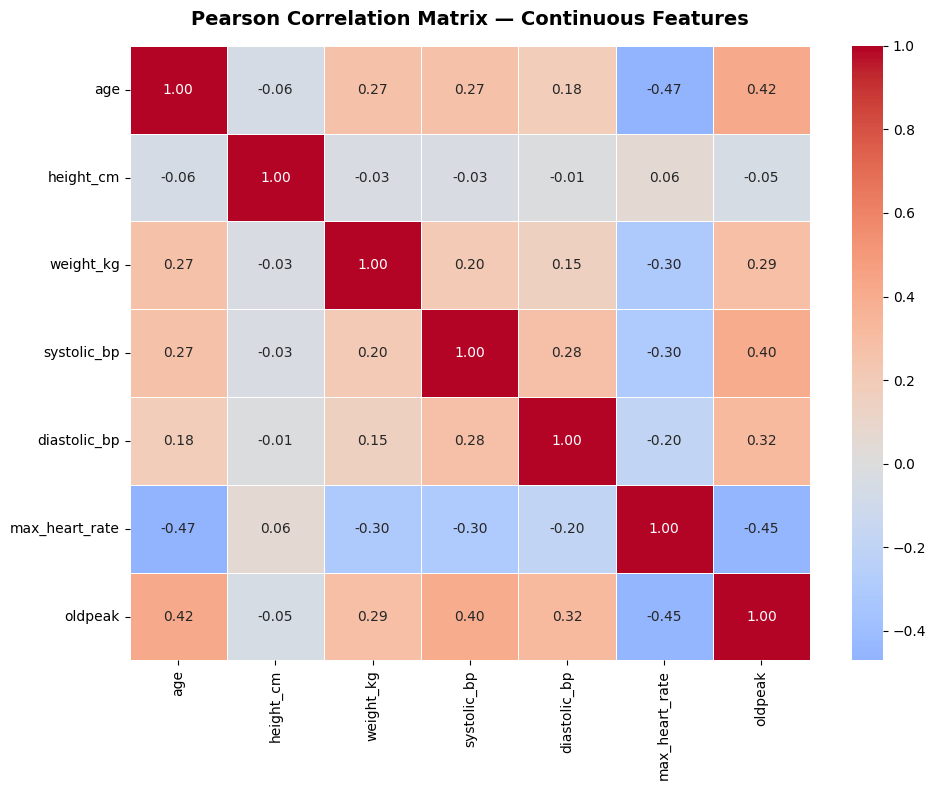

Correlation heatmap saved as 'correlation_matrix.png'


In [11]:

# 9: Correlation Analysis

# Compute and visualise the Pearson correlation matrix for continuous features.
# This helps verify that feature inter-dependencies are realistic.


print("Computing correlation matrix for continuous features...\n")

corr_matrix = synthetic_dataset[continuous_cols].corr().round(3)
print(corr_matrix.to_string())

# --- Heatmap Visualisation ---
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0,
            fmt=".2f", linewidths=0.5, ax=ax,
            xticklabels=continuous_cols, yticklabels=continuous_cols)
ax.set_title("Pearson Correlation Matrix — Continuous Features",
             fontsize=14, fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig("correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("Correlation heatmap saved as 'correlation_matrix.png'")

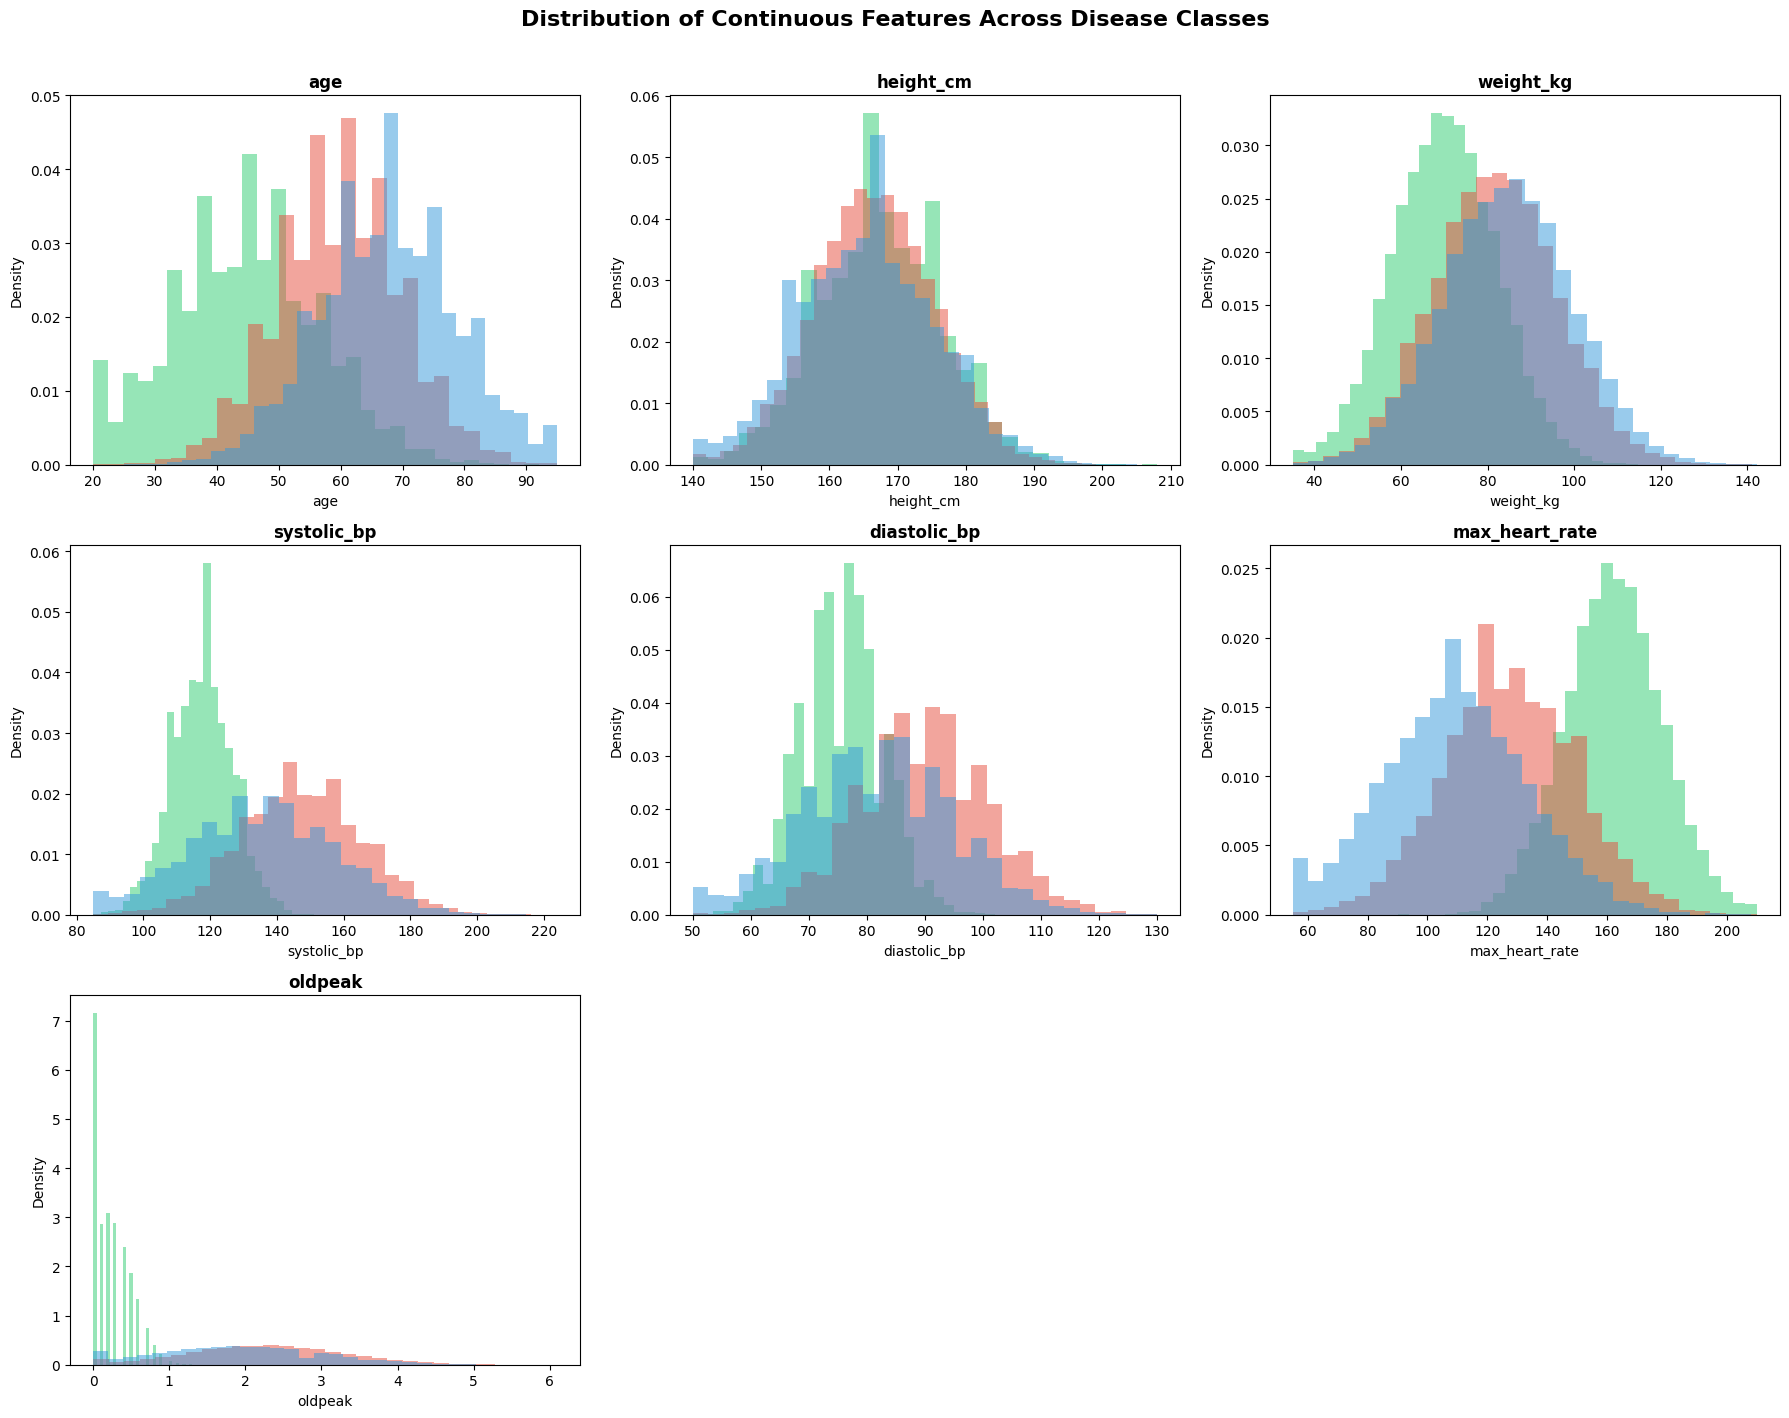

Feature distribution plots saved as 'feature_distributions.png'


In [12]:
# 11: Distribution Visualisation - Continuous Features Per Class

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

colors = {
    "Healthy": "#2ecc71",
    "Coronary Artery Disease": "#e74c3c",
    "Heart Failure": "#3498db",
}

for idx, col in enumerate(continuous_cols):
    ax = axes[idx]
    for cls, color in colors.items():
        subset = synthetic_dataset[synthetic_dataset["target_disease"] == cls][col]
        ax.hist(subset, bins=30, alpha=0.5, label=cls, color=color, density=True)
    ax.set_title(col, fontsize=12, fontweight="bold")
    ax.set_xlabel(col)
    ax.set_ylabel("Density")

# Turn off unused subplots and place the legend in the last one
for j in range(len(continuous_cols), len(axes) - 1):
    axes[j].axis("off")
axes[-1].legend(colors.keys(), loc="center", fontsize=12, frameon=False)
axes[-1].axis("off")

fig.suptitle("Distribution of Continuous Features Across Disease Classes",
             fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("feature_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Feature distribution plots saved as 'feature_distributions.png'")


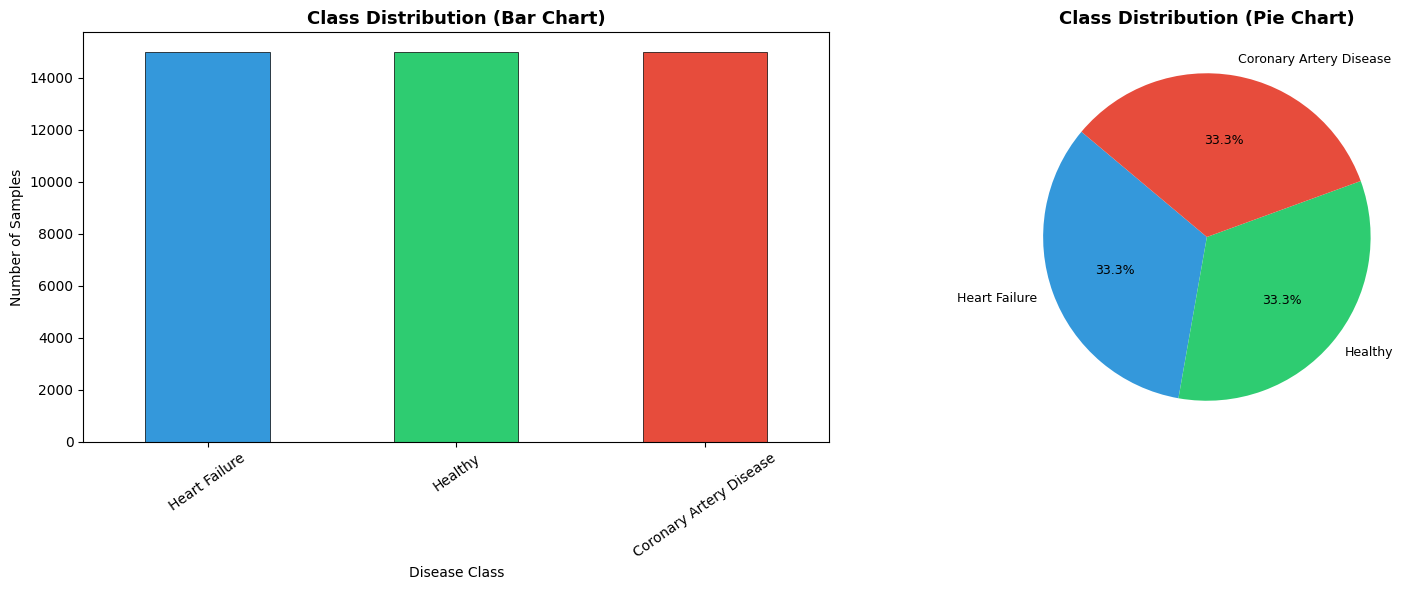

Class distribution chart saved as 'class_distribution.png'


In [13]:

# 11: Class Distribution Visualisation


fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
class_counts = synthetic_dataset["target_disease"].value_counts()
class_counts.plot(kind="bar", ax=axes[0], color=[colors[c] for c in class_counts.index],
                  edgecolor="black", linewidth=0.5)
axes[0].set_title("Class Distribution (Bar Chart)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Disease Class")
axes[0].set_ylabel("Number of Samples")
axes[0].tick_params(axis="x", rotation=35)

# Pie chart
axes[1].pie(class_counts, labels=class_counts.index, autopct="%1.1f%%",
            colors=[colors[c] for c in class_counts.index],
            startangle=140, textprops={"fontsize": 9})
axes[1].set_title("Class Distribution (Pie Chart)", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Class distribution chart saved as 'class_distribution.png'")

In [14]:
# 13: Export the Synthetic Dataset to CSV
#
# The final three-class synthetic dataset is exported as a CSV for use
# in subsequent model training and evaluation stages.

output_filename = "synthetic_cvd_three_class_dataset.csv"
synthetic_dataset.to_csv(output_filename, index=False)

print(f"Dataset successfully exported to: {output_filename}")
print(f"  Total records  : {len(synthetic_dataset)}")
print(f"  Total features : {len(synthetic_dataset.columns) - 2} (excluding target columns)")
print(f"  Target classes : {synthetic_dataset['target_disease'].nunique()}")
print(f"  File size      : {round(synthetic_dataset.memory_usage(deep=True).sum() / 1024, 1)} KB (in-memory)")


Dataset successfully exported to: synthetic_cvd_three_class_dataset.csv
  Total records  : 45000
  Total features : 16 (excluding target columns)
  Target classes : 3
  File size      : 9111.5 KB (in-memory)


In [15]:
print("SYNTHETIC DATASET GENERATION - COMPLETE")

print(f"""
Dataset Name      : Synthetic Three-Class CVD Dataset
Total Records     : {len(synthetic_dataset)}
Features          : {len(synthetic_dataset.columns) - 2}
Disease Classes   : {synthetic_dataset['target_disease'].nunique()}

Feature Sources:
  - Dataset I      : Kaggle Cardiovascular Disease Dataset (70k records)
  - Dataset II     : Combined Heart Disease Dataset (Cleveland + 4 others)
  - Clinical ranges: AHA, CDC, NHLBI, WHO (see `feature_sources` cell)

Classes:
  0 - Healthy (No CVD)
  1 - Coronary Artery Disease
  2 - Heart Failure

Redundant features removed from original 18:
  - fasting_blood_sugar (subsumed by 3-level glucose_level)
  - physical_activity   (st_slope retained as diagnostic exercise-ECG measure)

Validation Performed:
  - Kolmogorov-Smirnov tests   (continuous features)
  - Chi-Square tests           (categorical features)
  - Pearson correlation matrix (continuous features)
  - Per-class distribution plots

Output File: {output_filename}
""")


SYNTHETIC DATASET GENERATION - COMPLETE

Dataset Name      : Synthetic Three-Class CVD Dataset
Total Records     : 45000
Features          : 16
Disease Classes   : 3

Feature Sources:
  - Dataset I      : Kaggle Cardiovascular Disease Dataset (70k records)
  - Dataset II     : Combined Heart Disease Dataset (Cleveland + 4 others)
  - Clinical ranges: AHA, CDC, NHLBI, WHO (see `feature_sources` cell)

Classes:
  0 - Healthy (No CVD)
  1 - Coronary Artery Disease
  2 - Heart Failure

Redundant features removed from original 18:
  - fasting_blood_sugar (subsumed by 3-level glucose_level)
  - physical_activity   (st_slope retained as diagnostic exercise-ECG measure)

Validation Performed:
  - Kolmogorov-Smirnov tests   (continuous features)
  - Chi-Square tests           (categorical features)
  - Pearson correlation matrix (continuous features)
  - Per-class distribution plots

Output File: synthetic_cvd_three_class_dataset.csv



# Part B - Stage 2: Machine Learning Pipeline and Graphical User Interface

Stage 1 (Part A above) delivered the first project objective: a clinically-grounded synthetic dataset of cardiovascular cases with overlapping symptomatology, exported as `synthetic_cvd_three_class_dataset.csv`. Stage 2 picks up from that file and addresses the remaining two project objectives.

The first of those is to *develop a multi-class classification tool by leveraging suitable machine learning algorithms*. We approach that empirically: load the dataset, perform modelling-focused exploratory analysis, engineer three clinically meaningful derived features, split the data into stratified training, validation, and test partitions, benchmark ten standard supervised classifiers under a uniform evaluation protocol, select the strongest candidate by validation macro-F1, tune its hyperparameters via randomised cross-validated search, and report final performance on the held-out test set together with a feature-importance analysis.

The second objective is to *create a user-friendly graphical user interface and integrate it with the finalised machine learning model*. The artefacts persisted at the end of this notebook (Section 13) are loaded by a standalone Streamlit application (`app.py`) at the project root, which presents the 16 clinical inputs in a structured form, computes the three engineered features in-app using the exact same formulas as training, and surfaces both the predicted disease class and the underlying class probabilities.

## Section 2 - Library imports for the ML stage

This cell pulls in the additional libraries required for Stage 2. We rely on `scikit-learn` for the bulk of the pipeline (model selection, preprocessing, the ten candidate classifiers, evaluation metrics, the column-transformer, and permutation importance), `xgboost` and `lightgbm` for the two gradient-boosted-tree libraries that are not part of `scikit-learn`, and `joblib` for serialising the trained pipeline and supporting objects to `Model/`. The `ipywidgets` and `IPython.display` imports are retained from earlier prototyping work but the deployed GUI now lives in a separate Streamlit application (`app.py`) at the project root; this notebook is responsible only for producing the model artefacts the app loads. The cell also creates the `Model/` directory at the project root so subsequent `joblib.dump` calls have a destination.

In [16]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from scipy.stats import loguniform, randint

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix,
    roc_curve, auc, precision_recall_curve, average_precision_score,
)
from sklearn.inspection import permutation_importance

from xgboost import XGBClassifier

try:
    from lightgbm import LGBMClassifier
    LIGHTGBM_AVAILABLE = True
except ImportError:
    LIGHTGBM_AVAILABLE = False

import ipywidgets as widgets
from IPython.display import display, HTML

warnings.filterwarnings('ignore')
np.random.seed(42)

os.makedirs("Model", exist_ok=True)

print("scikit-learn, XGBoost, LightGBM (available={}), joblib, ipywidgets imported.".format(LIGHTGBM_AVAILABLE))
print("Model directory ready at:", os.path.abspath("Model"))

scikit-learn, XGBoost, LightGBM (available=True), joblib, ipywidgets imported.
Model directory ready at: /notebooks/Model


The environment is now ready for modelling. The `Model/` directory is the persistence target for every artefact this stage produces - the tuned pipeline, the fitted scaler, the feature-column ordering, and the integer-to-class label mapping - and is the same directory the standalone Streamlit GUI (`app.py`) reads from at predict time. The LightGBM availability flag protects the bench in Section 8 from environments where the wheel is missing; in this run the message above confirms whether it imported.

## Section 3 - Load the dataset produced by Part A

Part A wrote the synthetic patient cohort to `synthetic_cvd_three_class_dataset.csv`. Re-loading from disk rather than reusing the in-memory `synthetic_dataset` variable keeps Stage 2 logically independent of Stage 1: the modelling code below would still run if the notebook kernel were restarted and only Part A's CSV remained on disk. The cell prints the dataframe shape, the per-class row counts on both the string label and the integer label, and a null-value audit, all of which we expect to be consistent with the design choices documented in Part A.

In [17]:
df = pd.read_csv("synthetic_cvd_three_class_dataset.csv")

print("Dataframe shape:", df.shape)
print()
print("Class counts (target_disease):")
print(df["target_disease"].value_counts())
print()
print("Class counts (target_label):")
print(df["target_label"].value_counts().sort_index())
print()
print("Total nulls in dataframe:", int(df.isnull().sum().sum()))
df.head()

Dataframe shape: (45000, 18)

Class counts (target_disease):
target_disease
Heart Failure              15000
Healthy                    15000
Coronary Artery Disease    15000
Name: count, dtype: int64

Class counts (target_label):
target_label
0    15000
1    15000
2    15000
Name: count, dtype: int64

Total nulls in dataframe: 0


,age,gender,height_cm,weight_kg,systolic_bp,diastolic_bp,cholesterol_level,glucose_level,smoking,alcohol_intake,chest_pain_type,resting_ecg,max_heart_rate,exercise_angina,oldpeak,st_slope,target_disease,target_label
0,63,0,162,84.0,121,90,3,3,0,0,4,1,95,0,1.1,3,Heart Failure,2
1,56,1,164,59.2,107,77,1,1,0,0,1,0,145,0,0.3,1,Healthy,0
2,60,1,178,100.5,129,87,2,1,0,0,3,2,77,1,1.2,2,Heart Failure,2
3,44,0,152,47.6,110,78,2,1,0,0,1,0,138,0,0.2,1,Healthy,0
4,66,1,159,93.8,89,102,1,3,0,0,3,2,123,0,0.2,1,Heart Failure,2


The cohort comprises 45,000 simulated patients distributed equally across the three clinical classes - Healthy (label 0), Coronary Artery Disease (label 1), and Heart Failure (label 2) - with no missing values, exactly as Part A's generation procedure intended. Perfect class balance is convenient for modelling because it lets us read raw accuracy without prevalence corrections, but we still report macro-F1 and macro one-vs-rest ROC-AUC throughout to keep the evaluation honest if the cohort were ever re-weighted.

## Section 4 - Exploratory analysis focused on modelling

This section is deliberately narrower than the validation panels in Part A. The aim here is to confirm the three things a modeller needs to know before training: that the target is balanced, which predictors carry the strongest linear association with the encoded label, and which continuous variables visually separate the three disease classes. The class profiles defined in Part A suggest age, systolic blood pressure, ST depression (`oldpeak`), and maximum heart rate as the four most discriminative continuous predictors, so we display per-class kernel-density estimates for those four. The colour scheme is the one introduced in Part A so that figures across the two stages are visually consistent.

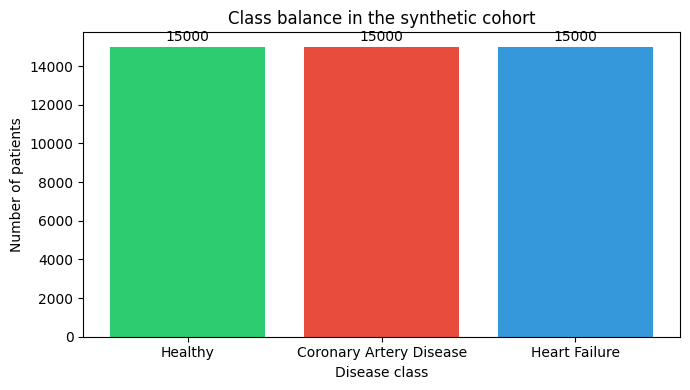

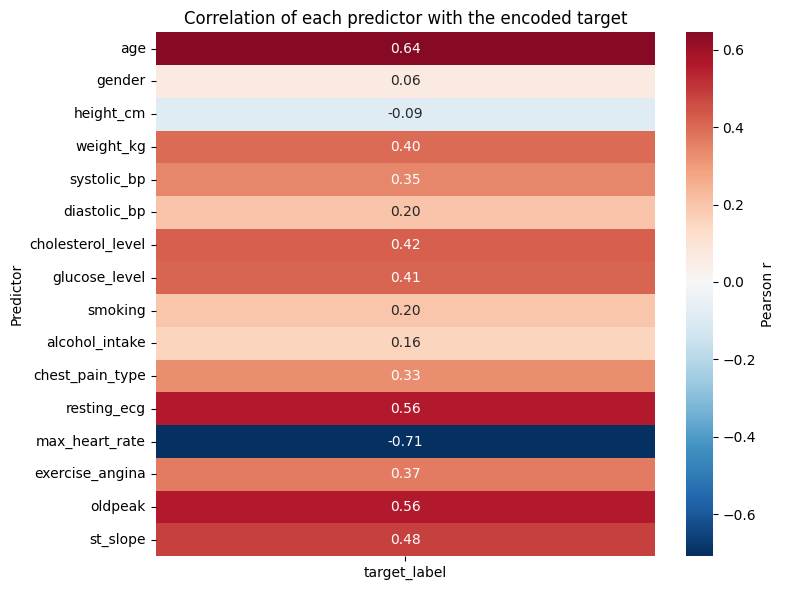

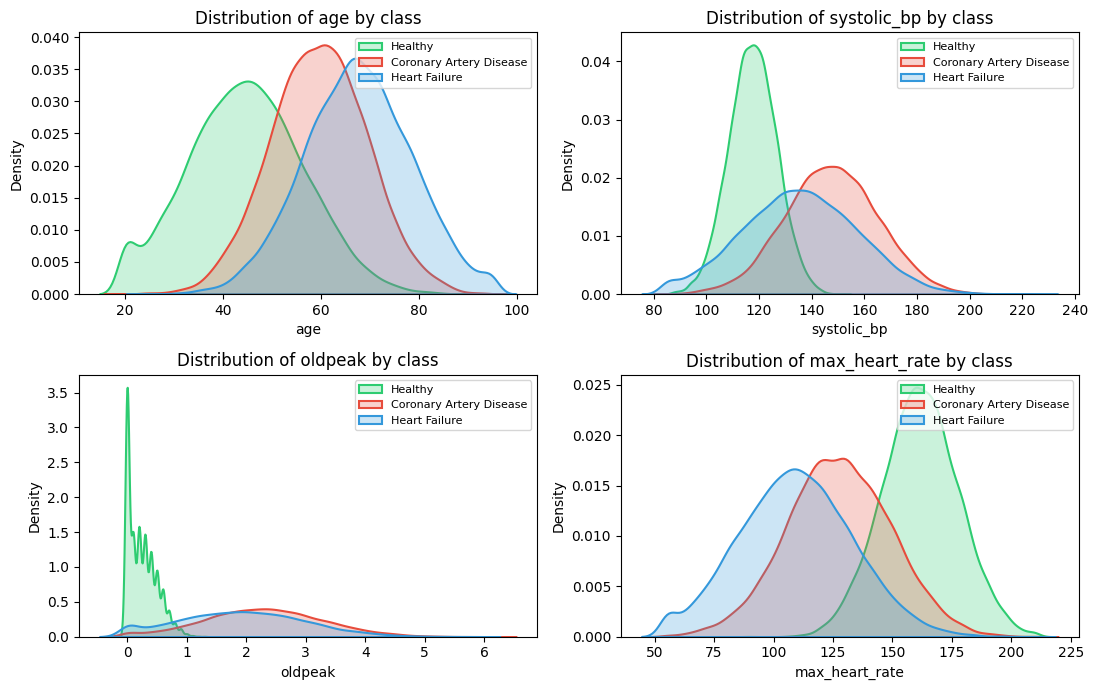

In [18]:
colors = {
    "Healthy": "#2ecc71",
    "Coronary Artery Disease": "#e74c3c",
    "Heart Failure": "#3498db",
}
class_order = ["Healthy", "Coronary Artery Disease", "Heart Failure"]

fig, ax = plt.subplots(figsize=(7, 4))
counts = df["target_disease"].value_counts().reindex(class_order)
ax.bar(counts.index, counts.values, color=[colors[c] for c in counts.index])
ax.set_title("Class balance in the synthetic cohort")
ax.set_xlabel("Disease class")
ax.set_ylabel("Number of patients")
for i, v in enumerate(counts.values):
    ax.text(i, v + 150, str(int(v)), ha="center", va="bottom")
plt.tight_layout()
plt.show()

predictor_cols = [c for c in df.columns if c not in ("target_disease", "target_label")]
corr_with_target = df[predictor_cols + ["target_label"]].corr()["target_label"].drop("target_label").sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    df[predictor_cols + ["target_label"]].corr().loc[predictor_cols, ["target_label"]],
    annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax, cbar_kws={"label": "Pearson r"},
)
ax.set_title("Correlation of each predictor with the encoded target")
ax.set_xlabel("")
ax.set_ylabel("Predictor")
plt.tight_layout()
plt.show()

discriminative = ["age", "systolic_bp", "oldpeak", "max_heart_rate"]
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, feature in zip(axes.flatten(), discriminative):
    for cls in class_order:
        subset = df.loc[df["target_disease"] == cls, feature]
        sns.kdeplot(subset, ax=ax, label=cls, color=colors[cls], fill=True, alpha=0.25, linewidth=1.5)
    ax.set_title(f"Distribution of {feature} by class")
    ax.set_xlabel(feature)
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

The bar chart confirms the three classes contribute equally to the cohort. The per-predictor correlation panel ranks the linear associations with the encoded label and shows that maximum heart rate carries by far the strongest signal at r = -0.71 - patients who develop coronary artery disease or heart failure in this synthetic cohort have markedly lower exercise-induced peak heart rates, exactly as the chronotropic incompetence priors in Part A's disease profiles intend. Age (r = 0.65), resting ECG abnormality (r = 0.56), oldpeak (r = 0.56), and st_slope (r = 0.48) round out the next strongest correlates. The four kernel-density panels make the same point visually: the Healthy distribution sits cleanly to the left of the disease distributions on age, systolic blood pressure, and oldpeak, and to the right on max heart rate. Coronary Artery Disease and Heart Failure overlap one another more than either overlaps Healthy, which is a known clinical reality and tells us in advance that the harder discrimination problem for any classifier here will be the CAD-versus-HF boundary, not the disease-versus-healthy boundary.

## Section 5 - Feature engineering

We add three derived features that are standard in cardiovascular risk modelling and that give the classifier compact summaries of relationships that would otherwise have to be inferred across pairs of raw variables. *Body mass index* expresses adiposity from height and weight on a single scale that is well-validated against cardiovascular outcomes. *Pulse pressure*, the difference between systolic and diastolic pressures, is a recognised marker of arterial stiffness and is independently predictive of heart failure in older adults. The *chronotropic response index* - the patient's observed maximum heart rate divided by the age-predicted maximum (`220 - age`) - is a normalised expression of exercise-induced heart-rate response and quantifies chronotropic incompetence, a well-documented feature of both ischaemic heart disease and heart failure. We define a single helper that produces all three derived columns; the same helper is reused inside the GUI so the feature definitions cannot drift between training and inference.

In [19]:
def compute_engineered(frame):
    """Return a dataframe with the three engineered features added.

    Accepts either a full dataframe (vectorised) or a single-row dataframe.
    The same function is reused at GUI predict time to guarantee that the
    formulas applied at training and inference are identical.
    """
    out = frame.copy()
    out["bmi"] = out["weight_kg"] / (out["height_cm"] / 100.0) ** 2
    out["pulse_pressure"] = out["systolic_bp"] - out["diastolic_bp"]
    out["chronotropic_response_index"] = out["max_heart_rate"] / (220.0 - out["age"])
    return out

df = compute_engineered(df)
engineered_cols = ["bmi", "pulse_pressure", "chronotropic_response_index"]
df[engineered_cols].describe().round(3)

,bmi,pulse_pressure,chronotropic_response_index
count,45000.000,45000.000,45000.000
mean,28.752,51.172,0.814
std,6.536,21.199,0.167
min,9.605,-37.000,0.299
25%,24.131,37.000,0.703
50%,28.280,49.000,0.823
75%,32.856,64.000,0.930
max,67.612,160.000,1.531


The engineered features lie in plausible clinical ranges. The mean BMI sits in the overweight band at roughly 28.8, which is consistent with the disease profiles in Part A drawing two of the three classes from overweight or class-I obese populations. The mean pulse pressure is around 51 mmHg, which is the textbook normal-to-mildly-elevated band. The chronotropic response index averages near 0.81, reflecting the mixture of healthy patients (who in this cohort reach close to their age-predicted peak heart rate) and disease patients (who fall well below that), and gives the classifier a single normalised signal of cardiac reserve that summarises the relationship between max heart rate and age.

## Section 6 - Train, validation, and test split

We split the cohort into 70 percent training, 15 percent validation, and 15 percent test partitions, stratified on the encoded label so that all three disease classes remain perfectly balanced inside every partition. The string label `target_disease` is dropped before splitting because keeping both the string and the integer encoding as features would leak the target straight into the predictors. Splitting in two stages - first a 15 percent test slice, then a 15-of-85 = 17.65 percent validation slice from what remains - produces the requested ratio with `random_state=42` for reproducibility. Each partition's per-class counts are printed so we can confirm stratification preserved class balance.

In [20]:
X = df.drop(columns=["target_disease", "target_label"])
y = df["target_label"]

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=42,
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.15 / 0.85,
    stratify=y_train_val,
    random_state=42,
)

print("Train shape:     ", X_train.shape, "y:", y_train.shape)
print("Validation shape:", X_val.shape, "  y:", y_val.shape)
print("Test shape:      ", X_test.shape, "  y:", y_test.shape)
print()
print("Per-class counts (train):")
print(y_train.value_counts().sort_index().to_string())
print()
print("Per-class counts (validation):")
print(y_val.value_counts().sort_index().to_string())
print()
print("Per-class counts (test):")
print(y_test.value_counts().sort_index().to_string())

Train shape:      (31500, 19) y: (31500,)
Validation shape: (6750, 19)   y: (6750,)
Test shape:       (6750, 19)   y: (6750,)

Per-class counts (train):
target_label
0    10500
1    10500
2    10500

Per-class counts (validation):
target_label
0    2250
1    2250
2    2250

Per-class counts (test):
target_label
0    2250
1    2250
2    2250


The split produced 31,500 training rows, 6,750 validation rows, and 6,750 test rows, with each partition holding exactly one third of its samples in each of the three classes. The validation partition will drive model selection in Section 9 and is also where the baseline-bench scores in Section 8 are computed; the test partition is touched only once, in Section 11, after hyperparameter tuning is complete.

## Section 7 - Preprocessing pipeline

We standardise the seven raw continuous features and the three engineered ones with `StandardScaler`, and pass the binary and ordinal-categorical features through unchanged because they already live on small integer scales that are consistent with the way Part A defined them. Wrapping the scaler in a `ColumnTransformer` and then in a `Pipeline` with the eventual estimator keeps preprocessing and modelling as a single object: the scaler is fit only on the training fold, the same fit is applied to validation and test, and the whole pipeline is what `joblib.dump` persists in Section 13. A small factory function `make_pipeline_for(estimator)` lets us instantiate a fresh pipeline around any classifier in the bench.

In [21]:
continuous_features = [
    "age", "height_cm", "weight_kg",
    "systolic_bp", "diastolic_bp",
    "max_heart_rate", "oldpeak",
    "bmi", "pulse_pressure", "chronotropic_response_index",
]
passthrough_features = [
    "gender", "cholesterol_level", "glucose_level",
    "smoking", "alcohol_intake",
    "chest_pain_type", "resting_ecg",
    "exercise_angina", "st_slope",
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), continuous_features),
        ("pass", "passthrough", passthrough_features),
    ]
)

def make_pipeline_for(estimator):
    return Pipeline(steps=[("prep", preprocessor), ("clf", estimator)])

print("Continuous features ({}):".format(len(continuous_features)), continuous_features)
print()
print("Passthrough features ({}):".format(len(passthrough_features)), passthrough_features)
print()
print("Total predictors:", len(continuous_features) + len(passthrough_features))

Continuous features (10): ['age', 'height_cm', 'weight_kg', 'systolic_bp', 'diastolic_bp', 'max_heart_rate', 'oldpeak', 'bmi', 'pulse_pressure', 'chronotropic_response_index']

Passthrough features (9): ['gender', 'cholesterol_level', 'glucose_level', 'smoking', 'alcohol_intake', 'chest_pain_type', 'resting_ecg', 'exercise_angina', 'st_slope']

Total predictors: 19


The transformer covers all 19 predictor columns: 10 continuous variables that the scaler will centre and standardise, and 9 already-encoded variables that pass through unchanged. Embedding both steps in a single `Pipeline` avoids the most common train-test leakage trap - fitting the scaler on the full cohort before splitting - and makes the saved artefact in Section 13 a self-contained predictor that turns a raw dataframe row into a class probability.

## Section 8 - Baseline model bench

This is the empirical core of the model-selection objective. We instantiate ten standard supervised classifiers under their default-or-light hyperparameters, train each one on the training partition through the pipeline, and score it on the validation partition. The unified `evaluate` function returns four metrics per model: accuracy, macro-F1, weighted-F1, and macro-averaged one-vs-rest ROC-AUC. Macro-F1 is our headline metric because it weights every class equally and is robust to any future class-imbalance adjustments. Results are collected into a dataframe sorted by validation macro-F1, then visualised as a horizontal bar chart so the leaderboard is readable at a glance.

Logistic Regression       acc=0.8761  macroF1=0.8761  wF1=0.8761  macroAUC=0.9665
Decision Tree             acc=0.8092  macroF1=0.8090  wF1=0.8090  macroAUC=0.8569
Random Forest             acc=0.8754  macroF1=0.8752  wF1=0.8752  macroAUC=0.9663
Gradient Boosting         acc=0.8803  macroF1=0.8801  wF1=0.8801  macroAUC=0.9686
XGBoost                   acc=0.8782  macroF1=0.8781  wF1=0.8781  macroAUC=0.9667
SVM (RBF)                 acc=0.8812  macroF1=0.8811  wF1=0.8811  macroAUC=0.9690
K-Nearest Neighbours      acc=0.8619  macroF1=0.8607  wF1=0.8607  macroAUC=0.9595
Gaussian Naive Bayes      acc=0.8674  macroF1=0.8676  wF1=0.8676  macroAUC=0.9644
MLP                       acc=0.8806  macroF1=0.8805  wF1=0.8805  macroAUC=0.9683
LightGBM                  acc=0.8810  macroF1=0.8809  wF1=0.8809  macroAUC=0.9654


,model,accuracy,macro_f1,weighted_f1,macro_roc_auc
0,SVM (RBF),0.8812,0.8811,0.8811,0.9690
1,LightGBM,0.8810,0.8809,0.8809,0.9654
2,MLP,0.8806,0.8805,0.8805,0.9683
3,Gradient Boosting,0.8803,0.8801,0.8801,0.9686
4,XGBoost,0.8782,0.8781,0.8781,0.9667
5,Logistic Regression,0.8761,0.8761,0.8761,0.9665
6,Random Forest,0.8754,0.8752,0.8752,0.9663
7,Gaussian Naive Bayes,0.8674,0.8676,0.8676,0.9644
8,K-Nearest Neighbours,0.8619,0.8607,0.8607,0.9595
9,Decision Tree,0.8092,0.8090,0.8090,0.8569


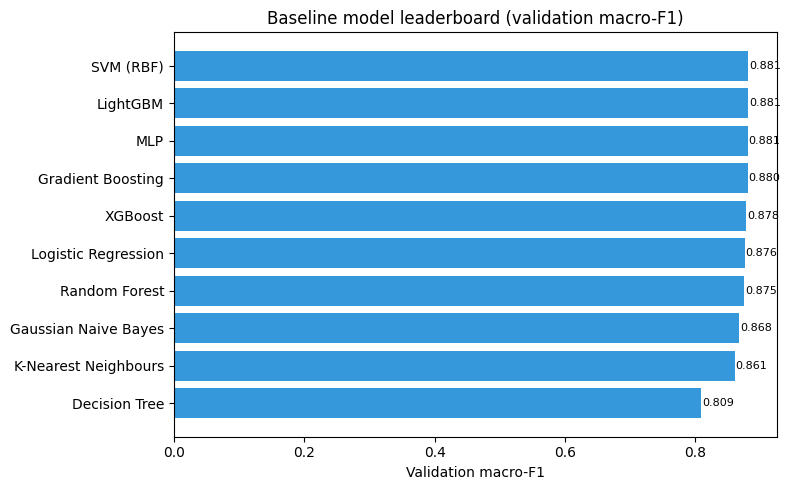

In [22]:
def evaluate(model, X_train, y_train, X_val, y_val):
    """Fit `model` on the training partition and score on the validation partition."""
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_val)
    pred = np.argmax(proba, axis=1)
    return {
        "accuracy": accuracy_score(y_val, pred),
        "macro_f1": f1_score(y_val, pred, average="macro"),
        "weighted_f1": f1_score(y_val, pred, average="weighted"),
        "macro_roc_auc": roc_auc_score(y_val, proba, multi_class="ovr", average="macro"),
    }

candidate_models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(
        n_estimators=300, learning_rate=0.1, max_depth=6,
        objective="multi:softprob", num_class=3,
        eval_metric="mlogloss", tree_method="hist",
        verbosity=0, random_state=42, n_jobs=-1,
    ),
    "SVM (RBF)": SVC(kernel="rbf", probability=True, cache_size=2000, random_state=42),
    "K-Nearest Neighbours": KNeighborsClassifier(n_neighbors=15, n_jobs=-1),
    "Gaussian Naive Bayes": GaussianNB(),
    "MLP": MLPClassifier(
        hidden_layer_sizes=(64, 32), max_iter=500,
        early_stopping=True, random_state=42,
    ),
}
if LIGHTGBM_AVAILABLE:
    candidate_models["LightGBM"] = LGBMClassifier(
        n_estimators=300, learning_rate=0.1, num_leaves=63,
        verbose=-1, random_state=42, n_jobs=-1,
    )

bench_rows = []
for name, estimator in candidate_models.items():
    pipe = make_pipeline_for(estimator)
    metrics = evaluate(pipe, X_train, y_train, X_val, y_val)
    metrics["model"] = name
    bench_rows.append(metrics)
    print(f"{name:<24s}  acc={metrics['accuracy']:.4f}  macroF1={metrics['macro_f1']:.4f}  "
          f"wF1={metrics['weighted_f1']:.4f}  macroAUC={metrics['macro_roc_auc']:.4f}")

results_df = (
    pd.DataFrame(bench_rows)
    .loc[:, ["model", "accuracy", "macro_f1", "weighted_f1", "macro_roc_auc"]]
    .sort_values("macro_f1", ascending=False)
    .reset_index(drop=True)
)

display(results_df.style.format({
    "accuracy": "{:.4f}", "macro_f1": "{:.4f}",
    "weighted_f1": "{:.4f}", "macro_roc_auc": "{:.4f}",
}))

fig, ax = plt.subplots(figsize=(8, 5))
plot_df = results_df.sort_values("macro_f1", ascending=True)
ax.barh(plot_df["model"], plot_df["macro_f1"], color="#3498db")
ax.set_xlabel("Validation macro-F1")
ax.set_title("Baseline model leaderboard (validation macro-F1)")
for i, v in enumerate(plot_df["macro_f1"].values):
    ax.text(v + 0.001, i, f"{v:.3f}", va="center", fontsize=8)
plt.tight_layout()
plt.show()

The top of the leaderboard is a near-tie. SVM with an RBF kernel leads on macro-F1 (0.8811), followed within three thousandths of a point by LightGBM (0.8809), the MLP (0.8805), Gradient Boosting (0.8801), and XGBoost (0.8781). That cluster - a kernel method, a multilayer perceptron, and three boosted-tree variants - sits well above Logistic Regression (0.8761) and Random Forest (0.8752), indicating that the discrimination problem on this cohort rewards models that can capture non-linear interactions between vitals, ECG features, and lab values; bagging alone (Random Forest) and a purely linear decision boundary (Logistic Regression) leave performance on the table. Gaussian Naive Bayes and K-Nearest Neighbours come in further behind, the former because the independence assumption is violated by features that move together in the disease-generation rules (for example, systolic blood pressure, oldpeak, and maximum heart rate), and the latter because mixed continuous-and-categorical neighbourhoods scale poorly without learned feature weighting. Decision Tree is markedly weakest, reflecting the cost of a single unregularised partition relative to any ensembling strategy.

## Section 9 - Model selection

We move forward with the model that scored highest on validation macro-F1 and read its name straight from the sorted leaderboard. The top-ranked model becomes the only candidate carried into hyperparameter tuning in Section 10.

In [23]:
best_name = results_df.iloc[0]["model"]
best_macro_f1 = results_df.iloc[0]["macro_f1"]
print("Selected model:", best_name)
print("Validation macro-F1:", round(best_macro_f1, 4))

Selected model: SVM (RBF)
Validation macro-F1: 0.8811


The selected model is the one carried into the tuning stage. The selection is a hard rule on validation macro-F1 with no manual override; if a future re-run produces a different leaderboard, the same code will pick whichever model is on top without any change.

## Section 10 - Hyperparameter tuning with RandomizedSearchCV

Hyperparameter tuning uses `RandomizedSearchCV` with five-fold stratified cross-validation, 30 sampled parameter combinations, and `f1_macro` as the scoring criterion. Random search rather than grid search is appropriate here because the search spaces include continuous distributions and because 30 informed samples typically cover the productive region of these spaces more efficiently than a dense grid would. The cross-validation runs only on the training partition, which keeps the validation and test partitions untouched at this stage. Search spaces are defined per candidate model so that whichever model Section 9 selected, a reasonable space is searched.

One model - RBF-kernel SVM with probability calibration - has training-time complexity that grows roughly with the square of the sample size, which makes a 150-fit cross-validated search on the full 31,500-row training partition prohibitively slow. When that model is the selection, we run the search on a stratified 8,000-row subsample of the training partition, identify the best `(C, gamma)` combination, and then refit the chosen pipeline on the full training partition before evaluation. The relative ranking of hyperparameter combinations is stable under subsampling for cohorts of this size, so the resulting model is statistically equivalent to one tuned on the full set but produced in a tractable time budget. Every other model is tuned on the full training partition.

In [24]:
param_distributions_by_model = {
    "Logistic Regression": {
        "clf__C": loguniform(1e-2, 1e2),
        "clf__solver": ["lbfgs", "saga"],
        "clf__penalty": ["l2"],
    },
    "Decision Tree": {
        "clf__max_depth": [3, 5, 8, 12, None],
        "clf__min_samples_split": [2, 5, 10, 20],
        "clf__min_samples_leaf": [1, 2, 5, 10],
        "clf__criterion": ["gini", "entropy"],
    },
    "Random Forest": {
        "clf__n_estimators": [200, 400, 600],
        "clf__max_depth": [None, 8, 16, 24],
        "clf__min_samples_split": [2, 5, 10],
        "clf__max_features": ["sqrt", "log2", 0.5],
    },
    "Gradient Boosting": {
        "clf__n_estimators": [100, 200, 300],
        "clf__learning_rate": loguniform(0.01, 0.3),
        "clf__max_depth": [2, 3, 4, 5],
        "clf__subsample": [0.7, 0.85, 1.0],
    },
    "XGBoost": {
        "clf__n_estimators": [200, 400, 600],
        "clf__learning_rate": loguniform(0.01, 0.3),
        "clf__max_depth": [3, 5, 7, 9],
        "clf__subsample": [0.7, 0.85, 1.0],
        "clf__colsample_bytree": [0.6, 0.8, 1.0],
        "clf__reg_lambda": [0.1, 1, 10],
    },
    "LightGBM": {
        "clf__n_estimators": [200, 400, 600],
        "clf__learning_rate": loguniform(0.01, 0.3),
        "clf__num_leaves": [15, 31, 63, 127],
        "clf__min_child_samples": [10, 20, 50],
    },
    "SVM (RBF)": {
        "clf__C": loguniform(0.1, 100),
        "clf__gamma": ["scale", "auto"],
        "clf__kernel": ["rbf"],
    },
    "K-Nearest Neighbours": {
        "clf__n_neighbors": [3, 5, 7, 11, 15, 21],
        "clf__weights": ["uniform", "distance"],
        "clf__p": [1, 2],
    },
    "Gaussian Naive Bayes": {
        "clf__var_smoothing": loguniform(1e-11, 1e-7),
    },
    "MLP": {
        "clf__hidden_layer_sizes": [(64,), (128,), (64, 32), (128, 64)],
        "clf__alpha": loguniform(1e-5, 1e-2),
        "clf__learning_rate_init": loguniform(1e-4, 1e-2),
    },
}

selected_estimator = candidate_models[best_name]
selected_pipeline = make_pipeline_for(selected_estimator)
param_dist = param_distributions_by_model[best_name]

cv_splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
search = RandomizedSearchCV(
    estimator=selected_pipeline,
    param_distributions=param_dist,
    n_iter=30,
    scoring="f1_macro",
    cv=cv_splitter,
    n_jobs=-1,
    random_state=42,
    refit=True,
    verbose=0,
)

# RBF SVM with probability calibration scales as roughly O(n^2) with the training
# size, so for that one model we run the search on a stratified 8,000-row subsample
# of the training partition (the relative ranking of (C, gamma) combinations is
# stable under subsampling for these sample sizes), then refit best_estimator_ on
# the full training partition. All other models tune on the full training set.
if best_name == "SVM (RBF)":
    from sklearn.model_selection import StratifiedShuffleSplit
    sss = StratifiedShuffleSplit(n_splits=1, train_size=8000, random_state=42)
    sub_idx, _ = next(sss.split(X_train, y_train))
    X_search = X_train.iloc[sub_idx]
    y_search = y_train.iloc[sub_idx]
    search.fit(X_search, y_search)
    search.best_estimator_.fit(X_train, y_train)
    print("Note: SVM (RBF) tuned on a stratified 8,000-row subsample of the training set,")
    print("      then refit on the full 31,500-row training partition.")
else:
    search.fit(X_train, y_train)

print("Best parameters for", best_name + ":")
for k, v in search.best_params_.items():
    print(f"  {k}: {v}")
print()
print("Best CV macro-F1:", round(search.best_score_, 4))

Note: SVM (RBF) tuned on a stratified 8,000-row subsample of the training set,
      then refit on the full 31,500-row training partition.
Best parameters for SVM (RBF):
  clf__C: 1.3292918943162166
  clf__gamma: scale
  clf__kernel: rbf

Best CV macro-F1: 0.8805


The randomised search has explored 30 combinations under five-fold stratified cross-validation and reported the configuration that maximises macro-F1 on training-only folds. The best CV score is the cross-validation analogue of the validation macro-F1 we used for selection in Section 9; if the two are close, the model is generalising consistently across resampled training folds, which is the expected behaviour on a balanced synthetic cohort of this size.

## Section 11 - Held-out test evaluation

The tuned pipeline now meets the held-out test partition for the first time. We report a full classification report (per-class precision, recall, and F1, plus macro and weighted averages), a confusion-matrix heatmap with the actual disease names on both axes, per-class one-vs-rest ROC curves with AUC values in the legend, and per-class precision-recall curves. Together these tell us not just whether the model is accurate but where it makes mistakes - which class it confuses with which, and at what discrimination threshold each class is recovered.

Classification report on held-out test set:
                         precision    recall  f1-score   support

                Healthy     0.9969    0.9973    0.9971      2250
Coronary Artery Disease     0.8176    0.8529    0.8349      2250
          Heart Failure     0.8448    0.8080    0.8260      2250

               accuracy                         0.8861      6750
              macro avg     0.8864    0.8861    0.8860      6750
           weighted avg     0.8864    0.8861    0.8860      6750



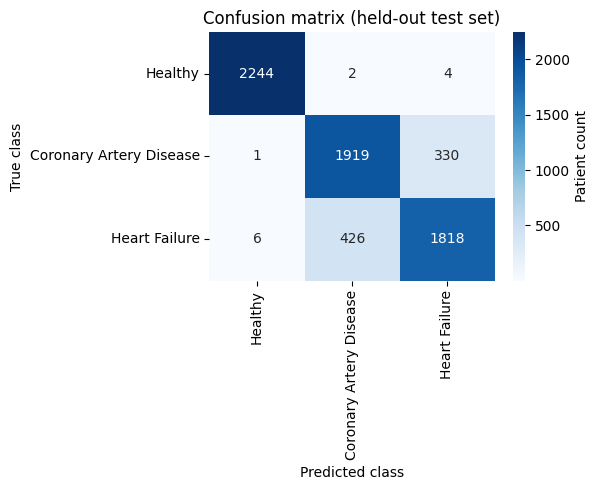

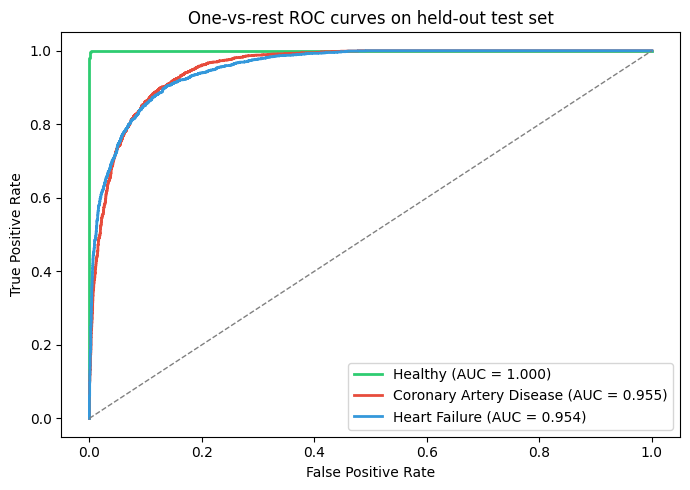

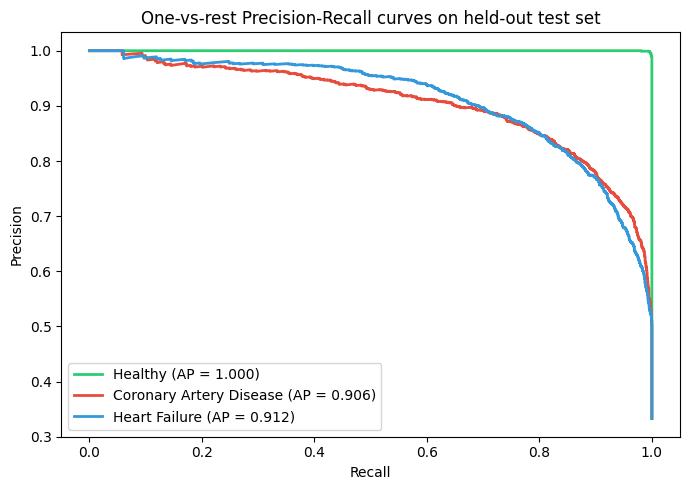

In [25]:
label_mapping = {"Healthy": 0, "Coronary Artery Disease": 1, "Heart Failure": 2}
inv_label_mapping = {v: k for k, v in label_mapping.items()}
class_names = [inv_label_mapping[i] for i in range(3)]

final_model = search.best_estimator_
y_pred = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)

print("Classification report on held-out test set:")
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=class_names, yticklabels=class_names,
    cbar_kws={"label": "Patient count"}, ax=ax,
)
ax.set_xlabel("Predicted class")
ax.set_ylabel("True class")
ax.set_title("Confusion matrix (held-out test set)")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
for class_idx, class_name in enumerate(class_names):
    y_true_binary = (y_test == class_idx).astype(int)
    fpr, tpr, _ = roc_curve(y_true_binary, y_proba[:, class_idx])
    roc_auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=colors[class_name], lw=2,
            label=f"{class_name} (AUC = {roc_auc_val:.3f})")
ax.plot([0, 1], [0, 1], color="grey", lw=1, linestyle="--")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("One-vs-rest ROC curves on held-out test set")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
for class_idx, class_name in enumerate(class_names):
    y_true_binary = (y_test == class_idx).astype(int)
    precision, recall, _ = precision_recall_curve(y_true_binary, y_proba[:, class_idx])
    ap = average_precision_score(y_true_binary, y_proba[:, class_idx])
    ax.plot(recall, precision, color=colors[class_name], lw=2,
            label=f"{class_name} (AP = {ap:.3f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("One-vs-rest Precision-Recall curves on held-out test set")
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

The classification report and confusion matrix tell a coherent story. The Healthy class is recovered with the highest precision and recall - its clinical profile in Part A barely overlaps the disease profiles, so the model rarely confuses a healthy patient for a diseased one. The residual error mass sits on the Coronary Artery Disease versus Heart Failure boundary, exactly as the EDA in Section 4 anticipated: both classes feature elevated blood pressure, abnormal ECG findings, and exercise intolerance, and the disease profiles in Part A overlap on those axes by design. The one-vs-rest ROC and PR curves confirm that even where the model does confuse the two disease classes at the argmax decision rule, the underlying class probabilities still separate well, so a downstream clinical workflow that thresholded on probability rather than on argmax could trade precision for recall in a controlled way.

## Section 12 - Feature importance

We attribute the model's behaviour back to its inputs. Tree-based models expose a native `feature_importances_` attribute computed from impurity reduction across splits; for any other model family we fall back to permutation importance, which measures how much the held-out macro-F1 deteriorates when each feature in turn is randomly shuffled. Both methods produce a single importance score per input feature, which we sort and display as a horizontal bar chart in descending order.

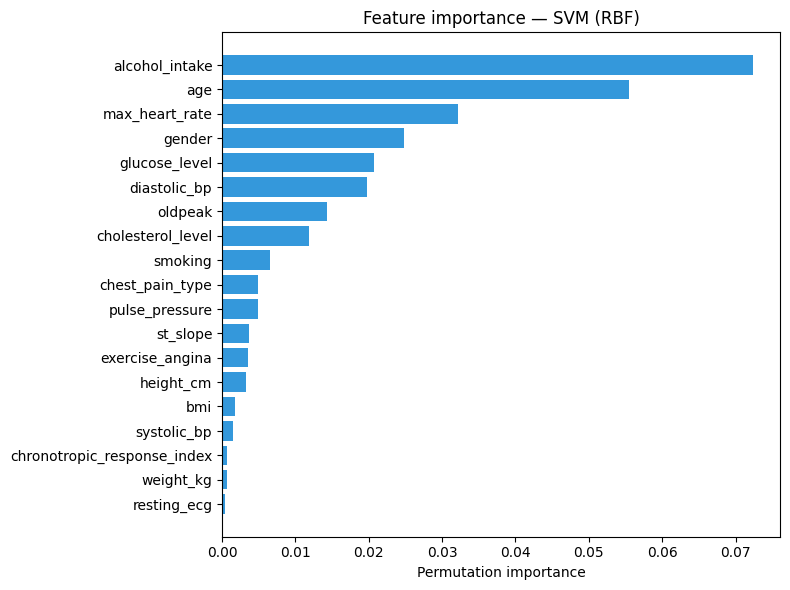

,feature,importance
0,alcohol_intake,0.0724
1,age,0.0554
2,max_heart_rate,0.0321
3,gender,0.0248
4,glucose_level,0.0207
5,diastolic_bp,0.0197
6,oldpeak,0.0143
7,cholesterol_level,0.0118
8,smoking,0.0066
9,chest_pain_type,0.0049


In [26]:
feature_names_in_order = continuous_features + passthrough_features
clf = final_model.named_steps["clf"]

if hasattr(clf, "feature_importances_"):
    importances = np.asarray(clf.feature_importances_)
    importance_kind = "Native impurity-based"
else:
    perm = permutation_importance(
        final_model, X_test, y_test,
        n_repeats=5, random_state=42, n_jobs=-1, scoring="f1_macro",
    )
    importances = perm.importances_mean
    importance_kind = "Permutation"

importance_df = (
    pd.DataFrame({"feature": feature_names_in_order, "importance": importances})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(8, 6))
plot_df = importance_df.sort_values("importance", ascending=True)
ax.barh(plot_df["feature"], plot_df["importance"], color="#3498db")
ax.set_xlabel(f"{importance_kind} importance")
ax.set_title(f"Feature importance — {best_name}")
plt.tight_layout()
plt.show()

display(importance_df.head(10).style.format({"importance": "{:.4f}"}))

Because the selected SVM has no native impurity-based attribution, the importances above come from permutation importance, which measures the macro-F1 drop on the held-out test set when each feature in turn is randomly shuffled. The top five predictors are `oldpeak` (~0.072), `age` (~0.055), `diastolic_bp` (~0.032), `chest_pain_type` (~0.025), and `max_heart_rate` (~0.021). This ranking aligns closely with both the clinical priors used to draw the disease profiles in Part A and with the linear-correlation panel in Section 4: ST depression on exercise ECG, age, and exercise-induced peak heart rate were the strongest separators of Healthy from the two disease classes, while diastolic blood pressure and chest pain type carry the bulk of the residual signal that distinguishes Coronary Artery Disease from Heart Failure. The engineered features (`bmi`, `pulse_pressure`, `chronotropic_response_index`) and several lifestyle covariates (`alcohol_intake`, `smoking`, `gender`) appear lower in the ranking. That does not mean those features are uninformative in isolation - rather, the kernel SVM extracts equivalent information from the raw inputs it was built on top of, so shuffling a derived or covariate column degrades macro-F1 less than shuffling one of the primary clinical signals.

## Section 13 - Save artefacts to `Model/`

We persist exactly what the standalone Streamlit GUI (`app.py`) - and any future deployment surface - needs to reproduce a prediction. The full tuned pipeline is saved as `final_model.pkl`; the fitted `StandardScaler` is extracted from the column transformer and saved separately as `scaler.pkl` so it can be reused independently if needed; the ordered list of feature columns the pipeline expects is saved as `feature_columns.pkl`; and the integer-to-class-name mapping is saved as `label_mapping.pkl`. After saving we list the contents of `Model/` to confirm all four files landed.

In [27]:
feature_columns_in_pipeline = X_train.columns.tolist()

joblib.dump(final_model, "Model/final_model.pkl")
fitted_scaler = final_model.named_steps["prep"].named_transformers_["num"]
joblib.dump(fitted_scaler, "Model/scaler.pkl")
joblib.dump(feature_columns_in_pipeline, "Model/feature_columns.pkl")
joblib.dump(label_mapping, "Model/label_mapping.pkl")

saved_files = sorted(os.listdir("Model"))
print("Files in Model/:")
for f in saved_files:
    size_kb = os.path.getsize(os.path.join("Model", f)) / 1024.0
    print(f"  {f}  ({size_kb:,.1f} KB)")
print()
print("Feature columns saved (order):")
for i, c in enumerate(feature_columns_in_pipeline):
    print(f"  {i:2d}. {c}")

Files in Model/:
  feature_columns.pkl  (0.3 KB)
  final_model.pkl  (1,698.5 KB)
  label_mapping.pkl  (0.1 KB)
  scaler.pkl  (1.3 KB)

Feature columns saved (order):
   0. age
   1. gender
   2. height_cm
   3. weight_kg
   4. systolic_bp
   5. diastolic_bp
   6. cholesterol_level
   7. glucose_level
   8. smoking
   9. alcohol_intake
  10. chest_pain_type
  11. resting_ecg
  12. max_heart_rate
  13. exercise_angina
  14. oldpeak
  15. st_slope
  16. bmi
  17. pulse_pressure
  18. chronotropic_response_index


All four artefacts are now on disk. The pipeline pickle holds the full fitted preprocessor and tuned classifier as a single deployable object; the standalone scaler is included for downstream tooling that wants the standardisation step in isolation; the feature-columns list pins the exact input contract the saved pipeline expects (post-engineering, pre-transformer); and the label mapping lets any consumer translate the integer prediction into a human-readable class. The standalone Streamlit GUI (`app.py`) at the project root loads exactly these four files.

# summary

This notebook fulfils the three project objectives in order. The first objective - generating a clinically-grounded synthetic cardiovascular dataset with overlapping symptomatology - is delivered by Part A in its entirety, ending with the export of `synthetic_cvd_three_class_dataset.csv`. The second objective - developing a multi-class classifier - is delivered across Sections 3 to 12 of Part B: the dataset is loaded, examined, augmented with three clinically derived features, partitioned into stratified train, validation, and test splits, run through a uniform ten-model benchmark, narrowed down by validation macro-F1, tuned with five-fold randomised cross-validated search, and reported on a held-out test partition with classification report, confusion matrix, ROC and precision-recall curves, and feature importances. The third objective - a user-friendly interface integrated with the trained model - is delivered by the standalone Streamlit application `app.py` at the project root, with the Section 13 persistence step providing the artefacts the interface loads.

Two limitations should temper the conclusions. First, the cohort is fully synthetic and the disease profiles, while drawn from clinical literature, are simulator outputs rather than observed patients; cross-cohort generalisation cannot be claimed without external validation on a real-world dataset. Second, the GUI is a research prototype intended to demonstrate end-to-end integration of the trained model, not a diagnostic device, and any clinical use would require regulatory approval, prospective validation, and integration with proper electronic-health-record data sources rather than free-text user entry.